In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
pronostico_meteorologia = pd.read_csv('../datos/meteorologia_veracruz_2026-04-20.csv')
pronostico_meteorologia

,date,time,temperature_C,pressure_hPa,wind_direction_deg,wind_speed_kmh,relative_humidity_pct,hourly_precip_mm
0,2026-04-19,18:00:00,25.442262,1014.498117,0.445976,35.072109,82.269247,0.000000
1,2026-04-19,19:00:11,24.972379,1014.033096,344.763235,40.910853,85.506366,0.000000
2,2026-04-19,20:00:22,24.871179,1016.531938,355.393888,36.728891,86.124573,0.000042
3,2026-04-19,21:00:00,24.661278,1017.149991,352.526289,37.874730,87.208287,0.000765
4,2026-04-19,22:00:00,24.423065,1018.389716,351.018923,39.270634,87.910058,0.001586
...,...,...,...,...,...,...,...,...
116,2026-04-24,14:00:09,26.788293,1003.307570,17.113561,17.438464,90.193662,0.000000
117,2026-04-24,15:00:00,27.118785,1002.342865,34.018649,17.797258,88.559443,0.000000
118,2026-04-24,16:00:11,27.406846,1002.150416,40.369953,13.144879,86.649562,0.000000
119,2026-04-24,17:00:11,27.319275,1001.286694,51.847129,13.599533,87.037744,0.000000


In [3]:
print(pronostico_meteorologia['date'][62]+" "+pronostico_meteorologia['time'][62])

2026-04-22 08:00:13


In [4]:
pronostico_meteorologia['hourly_precip_mm'][62]

np.float64(0.1355823820483556)

In [5]:
pronostico_meteorologia['wind_direction_deg'][62]

np.float64(107.13100068065962)

In [6]:
pronostico_meteorologia['Tiempo_datetime'] = pd.to_datetime(pronostico_meteorologia['date']+" "+pronostico_meteorologia['time'], 
                                                       format='%Y-%m-%d %H:%M:%S')
pronostico_meteorologia

,date,time,temperature_C,pressure_hPa,wind_direction_deg,wind_speed_kmh,relative_humidity_pct,hourly_precip_mm,Tiempo_datetime
0,2026-04-19,18:00:00,25.442262,1014.498117,0.445976,35.072109,82.269247,0.000000,2026-04-19 18:00:00
1,2026-04-19,19:00:11,24.972379,1014.033096,344.763235,40.910853,85.506366,0.000000,2026-04-19 19:00:11
2,2026-04-19,20:00:22,24.871179,1016.531938,355.393888,36.728891,86.124573,0.000042,2026-04-19 20:00:22
3,2026-04-19,21:00:00,24.661278,1017.149991,352.526289,37.874730,87.208287,0.000765,2026-04-19 21:00:00
4,2026-04-19,22:00:00,24.423065,1018.389716,351.018923,39.270634,87.910058,0.001586,2026-04-19 22:00:00
...,...,...,...,...,...,...,...,...,...
116,2026-04-24,14:00:09,26.788293,1003.307570,17.113561,17.438464,90.193662,0.000000,2026-04-24 14:00:09
117,2026-04-24,15:00:00,27.118785,1002.342865,34.018649,17.797258,88.559443,0.000000,2026-04-24 15:00:00
118,2026-04-24,16:00:11,27.406846,1002.150416,40.369953,13.144879,86.649562,0.000000,2026-04-24 16:00:11
119,2026-04-24,17:00:11,27.319275,1001.286694,51.847129,13.599533,87.037744,0.000000,2026-04-24 17:00:11


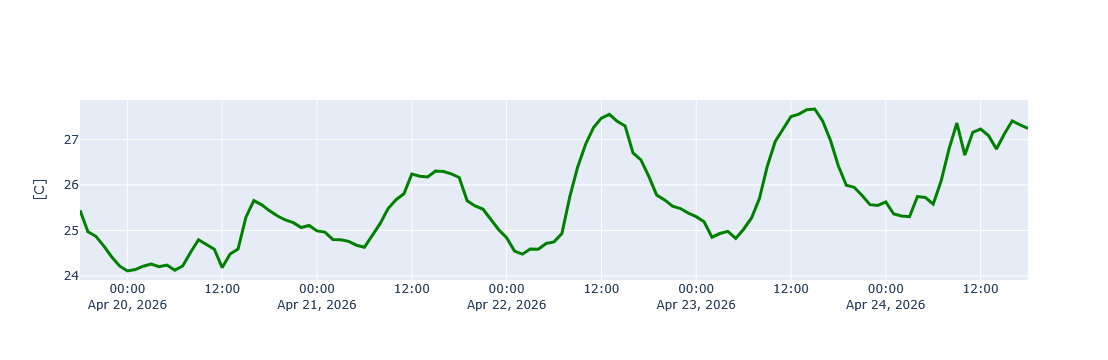

In [7]:
# Grafica pronostico de temperatura
fig = go.Figure()
fig.add_trace(go.Scatter(x=pronostico_meteorologia['Tiempo_datetime'],y=pronostico_meteorologia['temperature_C'],
                        line=dict(color='green',width=3)))
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[C]")
fig.show()

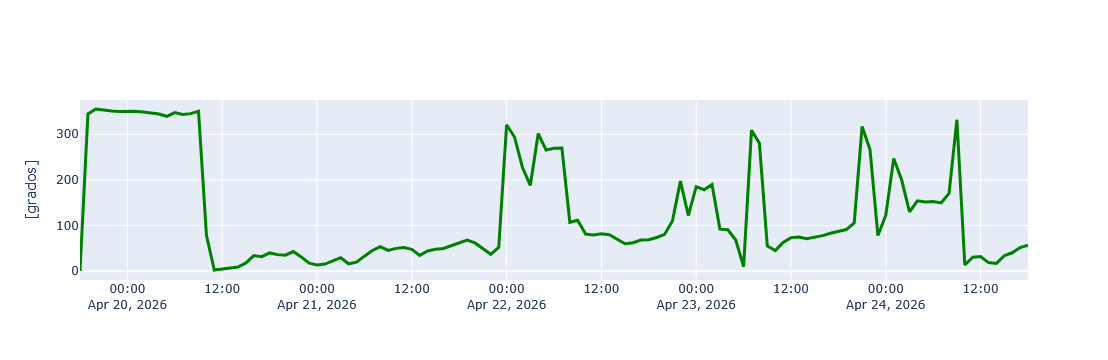

In [8]:
# Grafica pronostico dirección de viento
fig = go.Figure()
fig.add_trace(go.Scatter(x=pronostico_meteorologia['Tiempo_datetime'], y=pronostico_meteorologia['wind_direction_deg'],
                        line=dict(color='green',width=3)))
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[grados]")
fig.show()

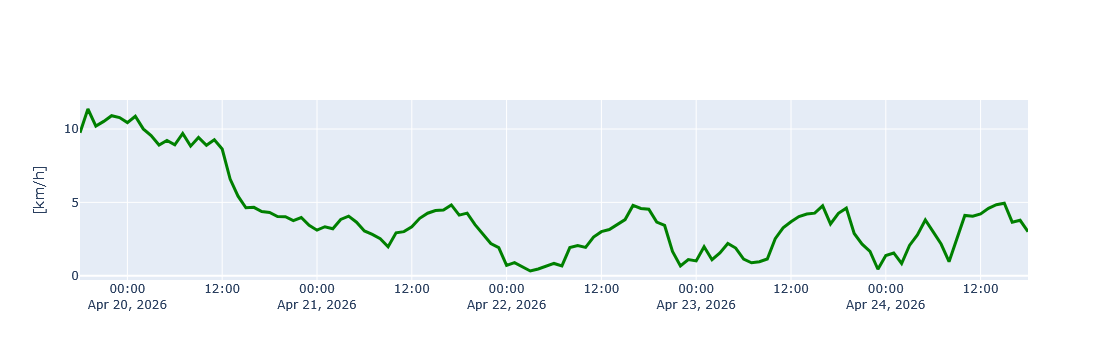

In [9]:
# Grafica pronostico velocidad de viento
pronostico_meteorologia['wind_speed_ms'] = (1000/3600) * pronostico_meteorologia['wind_speed_kmh']
fig = go.Figure()
fig.add_trace(go.Scatter(x=pronostico_meteorologia['Tiempo_datetime'], y=pronostico_meteorologia['wind_speed_ms'],
                        line=dict(color='green',width=3)))
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[km/h]")
fig.show()

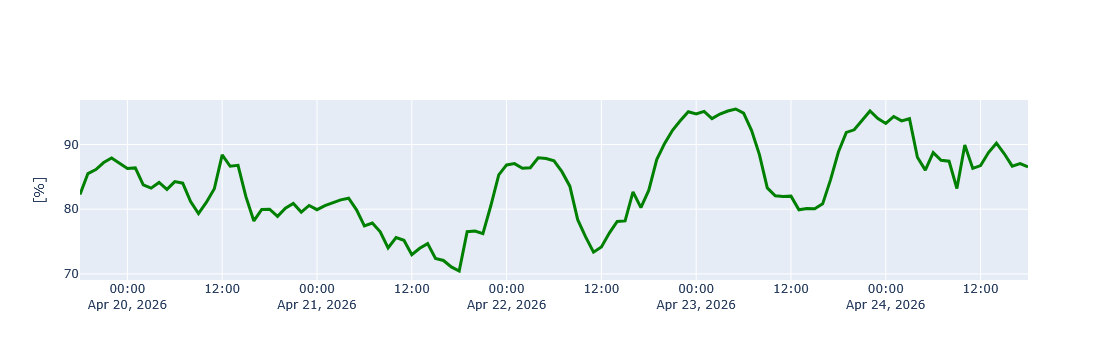

In [10]:
# Grafica pronostico humedad relativa
fig = go.Figure()
fig.add_trace(go.Scatter(x=pronostico_meteorologia['Tiempo_datetime'], y=pronostico_meteorologia['relative_humidity_pct'],
                        line=dict(color='green',width=3)))
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[%]")
fig.show()

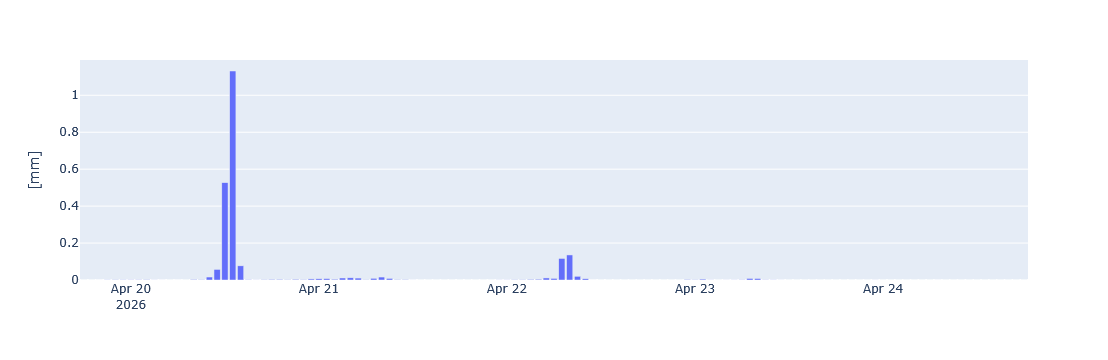

In [12]:
# Grafica pronostico precipitacion
fig = px.bar(pronostico_meteorologia, x=pronostico_meteorologia['Tiempo_datetime'], y=pronostico_meteorologia['hourly_precip_mm'])
fig.update_layout(xaxis_title=" ",
                  yaxis_title="[mm]")
fig.show()